# Gender differences across efficiency metrics

Show results for analysis:  
    - Matching acorss efficiency metrics, see `scripts/03_compute_nwmet_matching_byNk.py`  
    - Tour efficency gender gaps,see `scripts/07_anlayze_gender_diff_toureff.py`    

In [2]:
import pandas as pd
import pickle as pickle
import numpy as np
from scipy import stats

import networkx as nx

import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.ticker as ticker
from matplotlib.gridspec import GridSpec
import matplotlib.lines as mlines
from mpl_toolkits.axes_grid1 import make_axes_locatable

from utils.utils import GENDER, CTRY, COLOR
from utils.utils import set_mpl_style, log_to_km

In [3]:
## Set mpl Style
set_mpl_style()
cm_to_inch = 1/2.54
fs = 7

### Open results for matching exercise

In [ ]:
## OPEN RESULTS:
input_fig_path = ''
output_fig_path = ''

## --- Matching results across all countries ---
ctry = "all_ctry"
fname = f"{ctry}_res_knn_match.pkl"
with open(input_fig_path + fname, "rb") as f:
    res_knn = pickle.load(f)

In [23]:
## Define Metrics to explore
NAV_MLAB = [
    	"nwide_MFPT_lovasz",
        "home_GMFPT_lovasz",
        "global_efficiency_edges",    
        "global_efficiency_distance",
]

dMLAB = {
    	"nwide_MFPT_lovasz": "Network-wide\nMFPT",
        "home_GMFPT_lovasz": "Home-based\nMFPT",
        "global_efficiency_edges": "Global eff.\n(paths)",
        "global_efficiency_distance": "Global eff.\n(distance)",
}

### Open results for tour efficiency

In [ ]:
# OPEN SEQUENCE EFFICENCY BY REWARDS 
input_path = ''

## Open efficiency gender gap by reward
ctry = 'all_ctry'
fname = f'fig4_{ctry}_bs_gendergap_eff_by_totrewbins_Nquant.csv'
df_gengap_eff = pd.read_csv(input_path + fname)

display(df_gengap_eff.describe())

## Plot

In [ ]:
output_fig_path = ''

In [10]:
## Define plot parameters
TEST = [ "all", "inactive", "moderate", "active" ]
dTEST = {"inactive": "inactive (1st–3rd deciles)", "moderate": "moderate (4th–7th)", "active": "active (8th–10th)", "all": "all data"}

dTESTmarker = {
    "inactive": "v",
    "moderate": "d",
    "active": "^",    
    'all': "o",
}
dTESTsize = {
    "inactive": 2,
    "moderate": 2,
    "active": 2,
    'all': 7,
}

verbose = True

In [9]:
# Create custom colormap from 3 colors
colors = [COLOR['inactive'], COLOR['moderate'], COLOR['active']]
cmap = mpl.colors.LinearSegmentedColormap.from_list("my_cmap", colors, N=256)

# get color list by quantile
QUANTILES = [i for i in range(0, 5)] 
GRADCOLOR = [cmap(i / (len(QUANTILES) - 1)) for i in range(len(QUANTILES))]
norm = mpl.colors.Normalize(vmin=min(QUANTILES), vmax=max(QUANTILES))
sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

[nwide_MFPT_lovasz |    all]  true=+0.0123  pct=100.0%  p=0.0000  ***
[nwide_MFPT_lovasz | inactive]  true=-0.0104  pct= 10.8%  p=0.2160  ns
[nwide_MFPT_lovasz | moderate]  true=+0.0187  pct= 99.1%  p=0.0160  **
[nwide_MFPT_lovasz | active]  true=+0.0048  pct= 89.6%  p=0.2340  ns
[home_GMFPT_lovasz |    all]  true=+0.0734  pct=100.0%  p=0.0000  ***
[home_GMFPT_lovasz | inactive]  true=+0.0295  pct= 98.4%  p=0.0400  **
[home_GMFPT_lovasz | moderate]  true=+0.0782  pct=100.0%  p=0.0000  ***
[home_GMFPT_lovasz | active]  true=+0.0703  pct=100.0%  p=0.0000  ***
[global_efficiency_edges |    all]  true=-0.0162  pct=  0.0%  p=0.0000  ***
[global_efficiency_edges | inactive]  true=-0.0041  pct=  1.2%  p=0.0260  **
[global_efficiency_edges | moderate]  true=-0.0165  pct=  0.0%  p=0.0000  ***
[global_efficiency_edges | active]  true=-0.0172  pct=  0.0%  p=0.0000  ***
[global_efficiency_distance |    all]  true=-0.0126  pct=  0.0%  p=0.0000  ***
[global_efficiency_distance | inactive]  true=-0.0

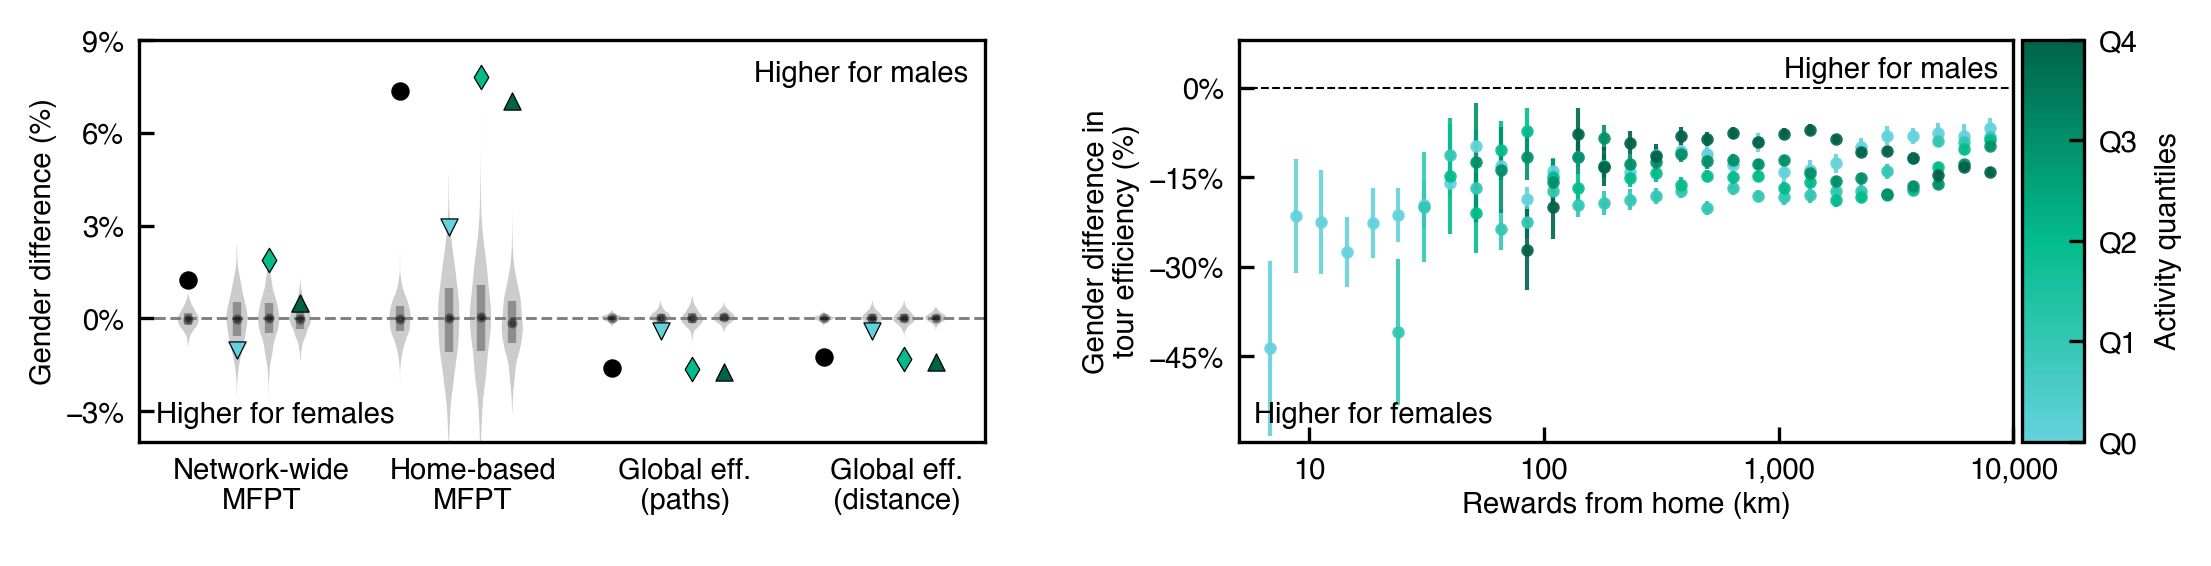

In [ ]:
## PANEL FOR FIGURE
fig = plt.figure(figsize=(18.3 * cm_to_inch, 5 * cm_to_inch))

gs = fig.add_gridspec(2, 1,  height_ratios= [20,1], hspace=0.35)

# -- Legend row
ax_leg = fig.add_subplot(gs[-1, :])  
for spine in ax_leg.spines.values():
    spine.set_visible(False)
ax_leg.set_xticks([])
ax_leg.set_yticks([])

#-- Efficency row
eff_gs = gs[0, :].subgridspec(1, 2, wspace = 0.3, width_ratios=[1,1])
ax_match = fig.add_subplot(eff_gs[0, 0])   
ax_seff_r = fig.add_subplot(eff_gs[0, 1])

# -- E. MATCHING EFF METRICS -----------------------------
for i, mlab in enumerate(NAV_MLAB):
    met = "rel_dif_" + mlab
    for i_buff, test in enumerate(TEST):

        res_true = res_knn[test]["True"]
        res_shuf = res_knn[test]["Shuffled"]

        data = 2 * res_true[met]["mean"]
        shuf_comb = [2 * e[met]["mean"] for e in res_shuf]

        # -- Percentile validation --
        if verbose:
            percentile_rank = stats.percentileofscore(shuf_comb, data, kind='rank')
            # Two-tailed p-value: how often does the null exceed the absolute deviation from median?
            shuf_median = np.median(shuf_comb)
            p_two_tailed = np.mean(np.abs(np.array(shuf_comb) - shuf_median) >= abs(data - shuf_median))
            
            sig_flag = "***" if p_two_tailed < 0.01 else "**" if p_two_tailed < 0.05 else "*" if p_two_tailed < 0.1 else "ns"
            print(f"[{mlab:>12s} | {test:>6s}]  true={data:+.4f}  "
                f"pct={percentile_rank:5.1f}%  p={p_two_tailed:.4f}  {sig_flag}")


        ## --- True difference in match pairs ---
        margin = 0.15 * i_buff if test != "all" else -0.08
        ax_match.scatter(
            i + margin,
            data,
            color=COLOR[test],
            s= 17,#30,
            marker=dTESTmarker[test],
            alpha=1,
            zorder=10,
            edgecolors='black',
            linewidths=0.3
        )
        
        ## --- Randomized baseline ---
        width = 0.1 #if test != "all" else 0.25
        parts = ax_match.violinplot(shuf_comb, showmeans=False, showmedians=False, showextrema=False, vert=True,
            positions=[i + margin], widths=width)

        alpha = 0.4
        for pc in parts['bodies']:
            pc.set_facecolor('grey')
            # pc.set_edgecolor('k')
            pc.set_alpha(alpha)

        # -- Baseline IQR
        q1, q2, q3 = np.percentile(shuf_comb, [25, 50, 75])
        median = np.median(shuf_comb)
        pos = i +  margin
        ax_match.vlines(pos, q1, q3, color='k', linewidth=2, alpha = 0.3, zorder = 7)
        ax_match.scatter(pos, q2, color='k', s = 2, alpha = 0.4, zorder = 8)

# -- Formatting axes
ax_match.axhline(0, color="grey", linestyle="--", linewidth=0.7, zorder=0)
ax_match.yaxis.set_major_formatter(mpl.ticker.PercentFormatter(1.0, decimals=0))
ax_match.yaxis.set_major_locator(mpl.ticker.MaxNLocator(nbins=5))

ax_match.set_xticks([i + (0.08+3*0.15)/2 for i in range(len(NAV_MLAB))])
ax_match.set_xticklabels([dMLAB[mlab] for mlab in NAV_MLAB], rotation=0, fontsize=fs)
ax_match.tick_params(axis="x", bottom=True, length=0)


ax_match.set_ylabel("Gender difference (%)", labelpad=2)
ax_match.set_ylim(-0.04, 0.09)

ax_match.text(0.98, 0.95, "Higher for males", transform=ax_match.transAxes, va="top", ha="right", color='k', fontsize=fs) # COLOR['MALE]
ax_match.text(0.02, 0.1, "Higher for females", transform=ax_match.transAxes, va="top", ha="left", color='k', fontsize=fs)



## -- G. SEQUENCE EFFICENCY BY REWARDS --------------------

# Plot by quantile
for q in QUANTILES:
    df_q = df_gengap_eff[df_gengap_eff['q_bin'] == q]
    ax_seff_r.errorbar(x = df_q['xbins_med'],  y = df_q['bs_median_reldiffsym'], yerr = df_q['bs_se_reldiffsym'],
            fmt = '.',  ms = 4, color=GRADCOLOR[q], alpha=0.9, linewidth = 1)
    
    # display(df_q.sort_values(['bs_median_reldiffsym'], ascending=True).head(3))

# Add a colorbar 
divider = make_axes_locatable(ax_seff_r)
cax = divider.append_axes("right", size="8%", pad=0.03)
cbar = fig.colorbar(sm, cax=cax, orientation="vertical", fraction=0.02, pad=0.04)
cbar.set_label(f"Activity quantiles")
cbar.set_ticks(QUANTILES)  # Set the quantiles as colorbar ticks
cbar_labels = [f"Q{int(q)}" for q in QUANTILES]  # Custom tick labels
cbar.ax.set_yticklabels(cbar_labels)  # Custom tick labels
cbar.ax.tick_params(which="both", direction="in")


# Format the plot
ax_seff_r.axhline(0, color='black', linestyle='--', linewidth=0.5)
ax_seff_r.yaxis.set_major_formatter(mpl.ticker.PercentFormatter(xmax=1, decimals=0))
ax_seff_r.yaxis.set_major_locator(mpl.ticker.MaxNLocator(nbins=5))

ymin = min(df_gengap_eff['bs_median_reldiffsym'] - df_gengap_eff['bs_se_reldiffsym'] - 0.01) # add 1pp margin
ymax = max(0.08, max(df_gengap_eff['bs_median_reldiffsym'] + df_gengap_eff['bs_se_reldiffsym']))
ax_seff_r.set_ylim([ymin, ymax]) 


# Add ticks and labels: one tick per integer log10 unit 
padding = 0
xmin = min(df_gengap_eff['xbins_med']) - padding # xmin = np.log10(0.2*30)
xmax = max(df_gengap_eff['xbins_med']) + padding # xmax =np.log10(300*30)
log_ticks = np.arange(min(0.7, np.floor(xmin)), max(5, np.ceil(xmax)), 1) # tick positions in log space
ax_seff_r.set_xticks(log_ticks)
ax_seff_r.xaxis.set_major_formatter(mpl.ticker.FuncFormatter(log_to_km))  # revert to km
ax_seff_r.set_xlim([min(0.7, xmin), max(4, xmax)]) 

ax_seff_r.set_xlabel('Rewards from home (km)', labelpad=2)
ax_seff_r.set_ylabel('Gender difference in\ntour efficiency (%)', labelpad=2)

ax_seff_r.text(0.98, 0.96, "Higher for males", transform=ax_seff_r.transAxes, va="top", ha="right", color='k', fontsize=fs)
ax_seff_r.text(0.02, 0.1, "Higher for females", transform=ax_seff_r.transAxes, va="top", ha="left", color='k', fontsize=fs)

fig.subplots_adjust(left=0.05, right=0.95, top=0.98, bottom=0.14)
plt.savefig(output_fig_path + "fig_4_eff.pdf", bbox_inches=None) # "tight"
plt.show() 

## SUPPLEMENTARY MATERIALS

In [ ]:
## S13. VIOLINS BY COUNTRY - MFPT:
input_path = ''
## --- Matching results by country ---
dic_RES = {}
for ctry in CTRY:
    fname = f"{ctry}_res_knn_match.pkl"
    with open(input_fig_path + fname, "rb") as f:
        res_ctry = pickle.load(f)
    dic_RES[ctry] = res_ctry

In [ ]:
## S13. PLOTS VIOLINS BY COUNTRY - MFPT:
fig, axs = plt.subplots(5, 2, figsize=(18.3 * cm_to_inch* 0.8, 16 * cm_to_inch), sharey=False, sharex=True)
fig.subplots_adjust(wspace=0.17, hspace=0.3)

for i, mlab in enumerate(NAV_MLAB): 
    for ax_match, ctry in zip(axs.flatten(), CTRY[::-1]):
        res_knn = dic_RES[ctry]       
        met = "rel_dif_" + mlab        
        for i_buff, test in enumerate(TEST): #['all']
    
            res_true = res_knn[test]["True"]
            res_shuf = res_knn[test]["Shuffled"]

            data = 2 * res_true[met]["mean"]
            shuf_comb = [2 * e[met]["mean"] for e in res_shuf]
            
            # -- Percentile validation --
            if verbose:
                percentile_rank = stats.percentileofscore(shuf_comb, data, kind='rank')
                # Two-tailed p-value: how often does the null exceed the absolute deviation from median?
                shuf_median = np.median(shuf_comb)
                p_two_tailed = np.mean(np.abs(np.array(shuf_comb) - shuf_median) >= abs(data - shuf_median))
                
                sig_flag = "***" if p_two_tailed < 0.01 else "**" if p_two_tailed < 0.05 else "*" if p_two_tailed < 0.1 else "ns"
                # print(f"[{mlab:>12s} | {test:>6s}]  true={data:+.4f}  "
                #     f"pct={percentile_rank:5.1f}%  p={p_two_tailed:.4f}  {sig_flag}")
                if sig_flag == "ns":
                    print(f"[{ctry} {mlab:>12s} | {test:>6s}]  true={data:+.4f}  "
                        f"pct={percentile_rank:5.1f}%  p={p_two_tailed:.4f}  {sig_flag}")
                    
            ## --- True difference in match pairs ---
            margin =  0.15 * i_buff if test != "all" else -0.08
            ax_match.scatter(
                i + margin,
                data,
                color=COLOR[test],
                s=6,
                marker=dTESTmarker[test],
                alpha=1,
                zorder=10,
            )
            
            ## --- Randomized baseline ---
            width = 0.1 #if test != "all" else 0.25
            parts = ax_match.violinplot(shuf_comb, showmeans=False, showmedians=False, showextrema=False, vert=True,
                positions=[i + margin], widths=width)

            # parts['cmedians'].set_color('grey')
            alpha = 0.3 #if test != "all" else 0.85
            for pc in parts['bodies']:
                pc.set_facecolor('grey')
                # pc.set_edgecolor('k')
                pc.set_alpha(alpha)

            # -- Baseline IQR
            q1, q2, q3 = np.percentile(shuf_comb, [25, 50, 75])
            median = np.median(shuf_comb)
            pos = i +  margin
            ax_match.vlines(pos, q1, q3, color='k', linewidth=2, alpha = 0.3, zorder = 7)
            ax_match.scatter(pos, q2, color='k', s = 2, alpha = 0.4, zorder = 8)


        # -- Formatting axes
        
        ax_match.axhline(0, color="grey", linestyle="--", linewidth=0.7, zorder=0)
        ax_match.yaxis.set_major_formatter(mpl.ticker.PercentFormatter(1.0, decimals=1))
        ax_match.yaxis.set_major_locator(mpl.ticker.MaxNLocator(nbins=5))


    ax_match.tick_params(axis="x", bottom=True, length=0)

    ax_match.set_title(ctry, pad=2)

axs[-1, 0].set_xticks([i for i in range(len(NAV_MLAB))])
axs[-1, 0].set_xticklabels([dMLAB[mlab] for mlab in NAV_MLAB], rotation=0, fontsize=fs-1)

axs[-1, 1].set_xticks([i for i in range(len(NAV_MLAB))])
axs[-1, 1].set_xticklabels([dMLAB[mlab] for mlab in NAV_MLAB], rotation=0, fontsize=fs-1)
axs[0,0].set_xlim(-0.5, len(NAV_MLAB)-0.5)

# axs[2,0].set_ylabel("Relative difference over the mean   "+ r"$\frac{M-F}{\frac{M+F}{2}}$"+" (%)", fontsize=fs, labelpad=1.5)
axs[2,0].set_ylabel('Gender difference (%)', fontsize=fs)
# fig.supxlabel("\nNetwork metrics assessment by activity level", fontsize=fs, y=0.05)

# ax_match.set_ylim(-0.1, 0.08)
# ax_match.axhspan(xmin=-0.2, xmax=len(NW_MLAB), ymin=-0.1, ymax=0, color=COLOR["FEMALE"], alpha=0.2, zorder=-1)
# ax_match.axhspan(xmin=-0.2, xmax=len(NW_MLAB), ymin=0, ymax=0.1, color=COLOR["MALE"], alpha=0.2, zorder=-1)
# ax_match.text(0.02, 0.95, "Higher for males", transform=ax_match.transAxes, va="top", ha="left", color='k', fontsize=fs) # COLOR['MALE]
# ax_match.text(0.02, 0.1, "Higher for females", transform=ax_match.transAxes, va="top", ha="left", color='k', fontsize=fs)

# plt.savefig(output_fig_path + "si_nav_matching_byctry_all.pdf", bbox_inches="tight")

In [ ]:
## S15. Cost - Reward 
input_path = ''

# ## Open cost gender gap by reward
ctry = 'all_ctry'
fname = f'fig4_{ctry}_bs_gendergap_cost_by_totrewbins_Nquant.csv'
df_gengap_cost = pd.read_csv(input_path + fname)
df_gengap_cost.describe().T

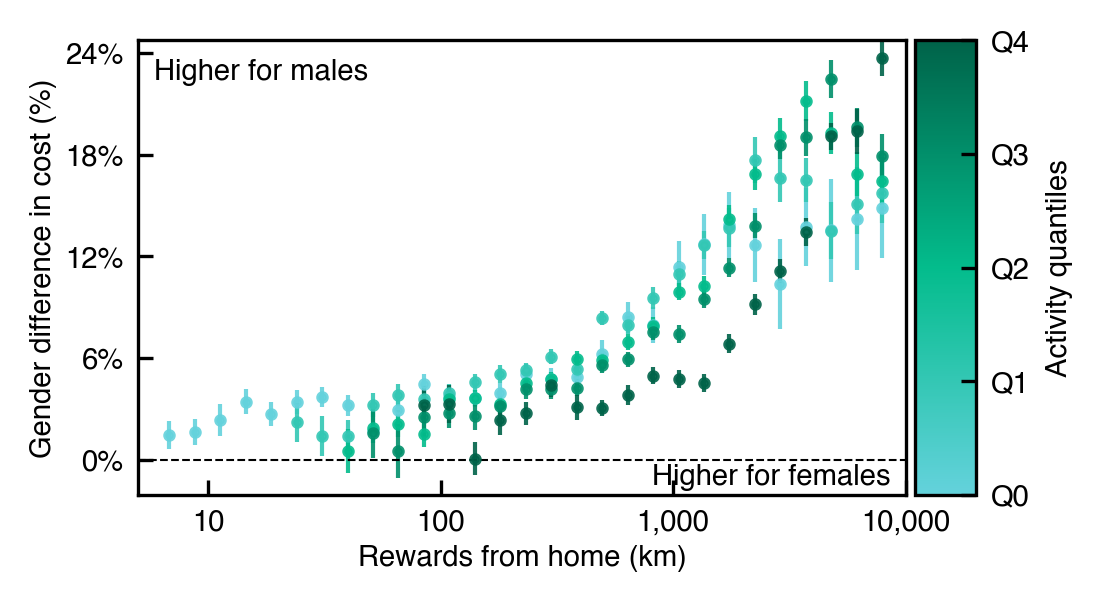

In [31]:
## PANEL FOR FIGURE
fig = plt.figure(figsize=(18.3 * cm_to_inch/2, 5 * cm_to_inch))
gs = fig.add_gridspec(1, 1)
ax_seff_r = fig.add_subplot(gs[0, 0])   



# Plot by quantile
for q in QUANTILES:
    df_q = df_gengap_cost[df_gengap_cost['q_bin'] == q]
    ax_seff_r.errorbar(x = df_q['xbins_med'],  y = df_q['bs_median_reldiffsym'], yerr = df_q['bs_se_reldiffsym'],
            fmt = '.',  ms = 4, color=GRADCOLOR[q], alpha=0.9, linewidth = 1)
    
    # display(df_q.sort_values(['bs_median_reldiffsym'], ascending=True).head(3))

# Add a colorbar 
divider = make_axes_locatable(ax_seff_r)
cax = divider.append_axes("right", size="8%", pad=0.03)
cbar = fig.colorbar(sm, cax=cax, orientation="vertical", fraction=0.02, pad=0.04)
cbar.set_label(f"Activity quantiles")
cbar.set_ticks(QUANTILES)  # Set the quantiles as colorbar ticks
cbar_labels = [f"Q{int(q)}" for q in QUANTILES]  # Custom tick labels
cbar.ax.set_yticklabels(cbar_labels)  # Custom tick labels
cbar.ax.tick_params(which="both", direction="in")


# Format the plot
ax_seff_r.axhline(0, color='black', linestyle='--', linewidth=0.5)
ax_seff_r.yaxis.set_major_formatter(mpl.ticker.PercentFormatter(xmax=1, decimals=0))
ax_seff_r.yaxis.set_major_locator(mpl.ticker.MaxNLocator(nbins=5))

ymin = min(df_gengap_cost['bs_median_reldiffsym'] - df_gengap_cost['bs_se_reldiffsym'] - 0.01) # add 1pp margin
ymax = max(0.08, max(df_gengap_cost['bs_median_reldiffsym'] + df_gengap_cost['bs_se_reldiffsym']))
ax_seff_r.set_ylim([ymin, ymax]) 
# print('ymin:', ymin, 'ymax:', ymax)


# Add ticks and labels: one tick per integer log10 unit 
padding = 0
xmin = min(df_gengap_cost['xbins_med']) - padding # xmin = np.log10(0.2*30)
xmax = max(df_gengap_cost['xbins_med']) + padding # xmax =np.log10(300*30)
log_ticks = np.arange(min(0.7, np.floor(xmin)), max(5, np.ceil(xmax)), 1) # tick positions in log space
ax_seff_r.set_xticks(log_ticks)
ax_seff_r.xaxis.set_major_formatter(mpl.ticker.FuncFormatter(log_to_km))  # revert to km
ax_seff_r.set_xlim([min(0.7, xmin), max(4, xmax)]) 
# print(log_ticks)
# print('xmin:', xmin, np.floor(xmin), 'xmax:', xmax, np.ceil(xmax), 'log_ticks:', log_ticks)

ax_seff_r.set_xlabel('Rewards from home (km)', labelpad=2)
ax_seff_r.set_ylabel('Gender difference in cost (%)', labelpad=2)

ax_seff_r.text(0.02, 0.96, "Higher for males", transform=ax_seff_r.transAxes, va="top", ha="left", color='k', fontsize=fs)
ax_seff_r.text(0.98, 0.01, "Higher for females", transform=ax_seff_r.transAxes, va="bottom", ha="right", color='k', fontsize=fs)

plt.savefig(output_fig_path + "si_cost_reward.pdf", bbox_inches="tight")

Processing JPN (1/10)...
Processing SWE (2/10)...
Processing ESP (3/10)...
Processing TWN (4/10)...
Processing GBR (5/10)...
Processing FRA (6/10)...
Processing USA (7/10)...
Processing DEU (8/10)...
Processing AUS (9/10)...
Processing NLD (10/10)...


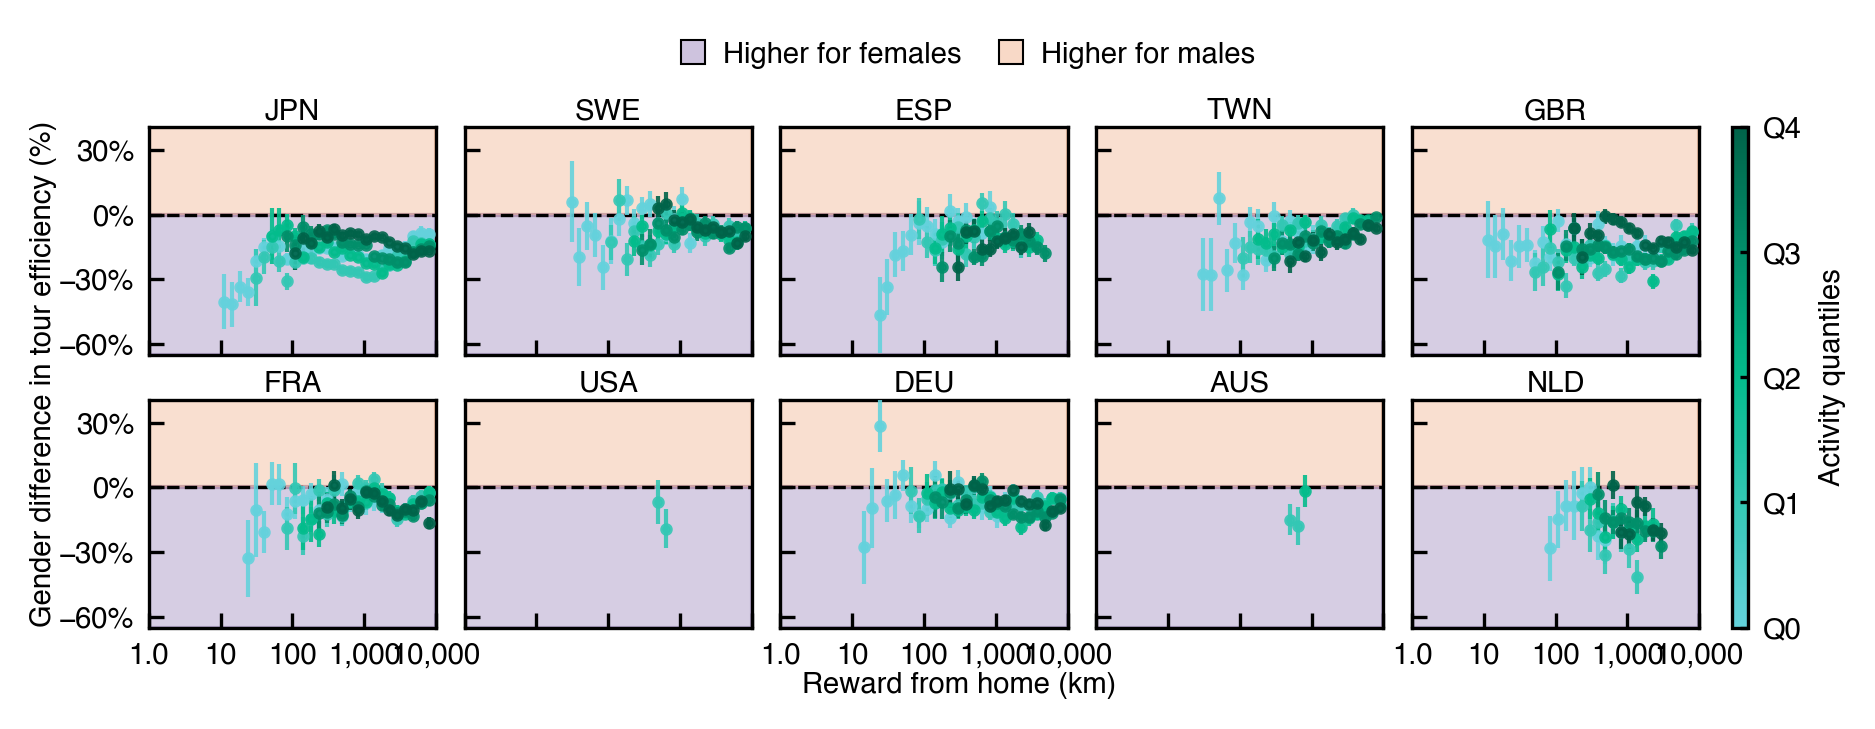

In [105]:
## SI16. Efficiency across countries

fig, axs = plt.subplots(2, 5, figsize=(18.3 * cm_to_inch, 5.5 * cm_to_inch),
                        sharey=True, sharex=True)
fig.subplots_adjust(wspace=0.1, hspace=0.2, right=0.88)

# --- Compute global y and x limits first (for consistent backgrounds with sharey/sharex) ---
all_ymin, all_ymax, all_xmin, all_xmax = [], [], [], []
for ctry in CTRY[::-1]:
    fname = f'fig4_{ctry}_bs_gendergap_eff_by_totrewbins_Nquant.csv'
    df = pd.read_csv(input_path + fname)
    df = df[df['xbins_med'] > 0.99]  
    if df.empty: continue
    all_ymin.append(min(df['bs_median_reldiffsym'] - df['bs_se_reldiffsym'] - 0.01))
    all_ymax.append(max(df['bs_median_reldiffsym'] + df['bs_se_reldiffsym']))
    all_xmin.append(min(df['xbins_med']))
    all_xmax.append(max(df['xbins_med']))

YMIN = min(all_ymin)
YMAX = max(0.08, max(all_ymax))
XMIN = min(0.9, min(all_xmin))
XMAX = max(4, max(all_xmax))


for i, (ctry, ax_seff_r) in enumerate(zip(CTRY[::-1], axs.flatten())):

    print(f"Processing {ctry} ({i+1}/{len(CTRY)})...")
    fname = f'fig4_{ctry}_bs_gendergap_eff_by_totrewbins_Nquant.csv'
    df_gengap_eff = pd.read_csv(input_path + fname)
    df_gengap_eff = df_gengap_eff[df_gengap_eff['xbins_med'] > 0.99]  

    if df_gengap_eff.empty:
        print(f"Warning: No data for {ctry}. Skipping.")
        continue

    # --- Set shared limits before drawing backgrounds ---
    ax_seff_r.set_xlim([XMIN, XMAX])
    ax_seff_r.set_ylim([YMIN, YMAX])

    # --- Colored backgrounds (now using global limits so they fill entire axes) ---
    ax_seff_r.axhspan(0, YMAX, color=COLOR['MALE'], alpha=0.25, zorder=0)
    ax_seff_r.axhspan(YMIN, 0, color=COLOR['FEMALE'], alpha=0.25, zorder=0)

    # --- Title ---
    ax_seff_r.set_title(ctry, pad=2, fontsize=fs)

    # --- Plot by quantile (using GRADCOLOR, consistent with colorbar) ---
    for q in QUANTILES:
        df_q = df_gengap_eff[df_gengap_eff['q_bin'] == q]
        ax_seff_r.errorbar(
            x=df_q['xbins_med'],
            y=df_q['bs_median_reldiffsym'],
            yerr=df_q['bs_se_reldiffsym'],
            fmt='.', ms=4, color=GRADCOLOR[q], alpha=0.9, linewidth=1, zorder=3
        )

    # --- Zero line ---
    ax_seff_r.axhline(0, color='k', linestyle='--', linewidth=0.8, zorder=2)

    # --- Y axis formatting (sharey handles hiding, just format) ---
    ax_seff_r.yaxis.set_major_formatter(mpl.ticker.PercentFormatter(xmax=1, decimals=0))
    ax_seff_r.yaxis.set_major_locator(mpl.ticker.MaxNLocator(nbins=4))

    # --- X axis ticks ---
    log_ticks = np.arange(np.floor(XMIN), np.ceil(XMAX) + 1, 1)
    ax_seff_r.set_xticks(log_ticks)
    ax_seff_r.xaxis.set_major_formatter(mpl.ticker.FuncFormatter(log_to_km))  # set formatter on ALL

    # Show labels only on bottom row (i >= 5) AND odd columns (i % 2 == 0)
    if i >= 5 and i % 2 == 1:
        ax_seff_r.tick_params(axis='x', labelbottom=True)
    else:
        ax_seff_r.tick_params(axis='x', labelbottom=False)


fig.supxlabel('Reward from home (km)', fontsize=fs, y=0)
fig.supylabel('Gender difference in tour efficiency (%)', fontsize=fs, x=0.07)

# --- Single shared colorbar: use GRADCOLOR to match errorbars exactly ---
cmap_grey = mpl.colors.LinearSegmentedColormap.from_list(
    'gradcolor', [GRADCOLOR[q] for q in sorted(QUANTILES)]
)
norm = mpl.colors.Normalize(vmin=min(QUANTILES), vmax=max(QUANTILES))
sm_grey = mpl.cm.ScalarMappable(cmap=cmap_grey, norm=norm)

cbar = fig.colorbar(sm_grey, ax=axs, orientation='vertical',
                    fraction=0.03, pad=0.02, aspect=30)
cbar.set_ticks(QUANTILES)
cbar.ax.set_yticklabels([f'Q{int(q)}' for q in QUANTILES], fontsize=fs)
cbar.ax.tick_params(which='both', direction='in', length=2)
cbar.set_label('Activity quantiles', fontsize=fs, labelpad=4)

## -- Legend ---
handle_background = [mpl.lines.Line2D([], [], markerfacecolor=mpl.colors.to_rgba(COLOR[gen], alpha=0.3),
    marker='s', markersize=4, linestyle='None',
    markeredgecolor='black', markeredgewidth=0.5,
    label="Higher for " + gen.lower() + 's') for gen in GENDER[::-1]]

leg = fig.legend(handles=handle_background, loc='lower center', bbox_to_anchor=(0.5, 0.93),
    frameon=False, ncol=4, fontsize=fs, handletextpad=0.02, columnspacing=0.7, markerscale=1.4)

plt.savefig(output_fig_path + "si_efficiency_countries.pdf", bbox_inches="tight")
plt.show()